# Customer Cluster Analysis

## Objective

The objective of this notebook is to analyze and interpret the customer segments generated by the K-Means clustering model.

This analysis aims to:

- Understand the characteristics of each customer segment.
- Compare customer behavior across clusters.
- Identify meaningful customer personas.
- Provide business recommendations for each segment.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")


In [5]:
clusters_df = pd.read_csv(
    "../../data/processed/customer_clusters.csv",
    parse_dates=["first_purchase", "last_purchase"]
)

### Basic Information

In [6]:
clusters_df.head()

,customer_unique_id,total_orders,total_spent,total_products,total_freight_paid,avg_order_value,avg_review_score,avg_delivery_days,first_purchase,last_purchase,customer_lifetime_days,recency_days,avg_basket_size,freight_ratio,R_score,F_score,M_score,RFM_score,Cluster
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,1.0,12.00,141.90,5.0,6.0,2018-05-10,2018-05-10,0,116,1.0,0.084567,4,1,4,414,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,1.0,8.29,27.19,4.0,3.0,2018-05-07,2018-05-07,0,119,1.0,0.304892,4,1,1,411,4
2,0000f46a3911fa3c0805444483337064,1,86.22,1.0,17.22,86.22,3.0,26.0,2017-03-10,2017-03-10,0,542,1.0,0.199722,1,1,2,112,2
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,1.0,17.63,43.62,4.0,20.0,2017-10-12,2017-10-12,0,326,1.0,0.404172,2,1,1,211,4
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,1.0,16.89,196.89,5.0,13.0,2017-11-14,2017-11-14,0,293,1.0,0.085784,2,1,4,214,1


In [7]:
clusters_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95419 entries, 0 to 95418
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   customer_unique_id      95419 non-null  str           
 1   total_orders            95419 non-null  int64         
 2   total_spent             95419 non-null  float64       
 3   total_products          95419 non-null  float64       
 4   total_freight_paid      95419 non-null  float64       
 5   avg_order_value         95419 non-null  float64       
 6   avg_review_score        94720 non-null  float64       
 7   avg_delivery_days       93355 non-null  float64       
 8   first_purchase          95419 non-null  datetime64[us]
 9   last_purchase           95419 non-null  datetime64[us]
 10  customer_lifetime_days  95419 non-null  int64         
 11  recency_days            95419 non-null  int64         
 12  avg_basket_size         95419 non-null  float64       
 1

In [8]:
clusters_df["Cluster"].value_counts().sort_index()

Cluster
0     1886
1    34289
2    15605
3    13288
4    30351
Name: count, dtype: int64

### Cluster size percentage

In [9]:
cluster_percentage = (
    clusters_df["Cluster"]
    .value_counts(normalize=True)
    .sort_index()
    *100
).round(2)

cluster_percentage

Cluster
0     1.98
1    35.94
2    16.35
3    13.93
4    31.81
Name: proportion, dtype: float64

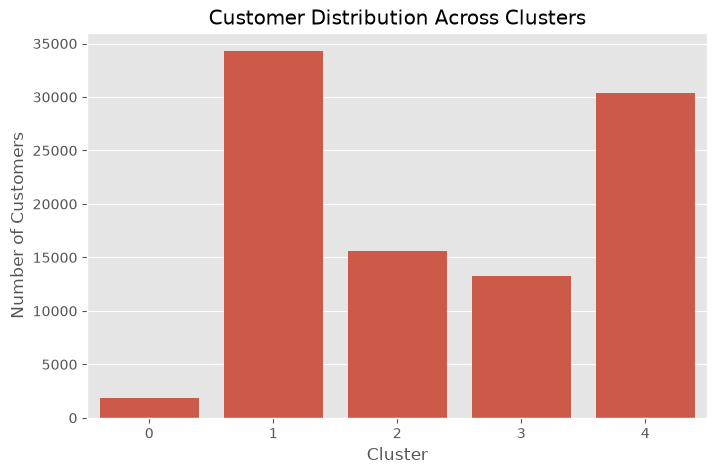

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=clusters_df,
    x="Cluster",
    order=sorted(clusters_df["Cluster"].unique())
)

plt.title("Customer Distribution Across Clusters")

plt.xlabel("Cluster")

plt.ylabel("Number of Customers")

plt.show()

## Cluster Profile

In [11]:
cluster_profile = (
    clusters_df
    .groupby("Cluster")
    .agg({
        "total_orders":"mean",
        "total_spent":"mean",
        "total_products":"mean",
        "avg_order_value":"mean",
        "avg_review_score":"mean",
        "avg_delivery_days":"mean",
        "customer_lifetime_days":"mean",
        "recency_days":"mean",
        "avg_basket_size":"mean",
        "freight_ratio":"mean"
    })
    .round(2)
)

cluster_profile

,total_orders,total_spent,total_products,avg_order_value,avg_review_score,avg_delivery_days,customer_lifetime_days,recency_days,avg_basket_size,freight_ratio
Cluster,,,,,,,,,,
0,2.16,321.28,2.66,148.26,4.26,11.80,135.31,192.56,1.22,0.19
1,1.00,171.88,1.03,171.43,4.69,10.43,0.00,243.55,1.02,0.12
2,1.01,160.72,1.20,159.46,1.54,20.29,0.01,251.88,1.19,0.21
3,1.04,394.00,1.67,385.73,4.43,14.51,0.03,236.07,1.61,0.21
4,1.00,52.83,1.04,52.64,4.61,10.40,0.00,245.54,1.03,0.31


### HeatMap

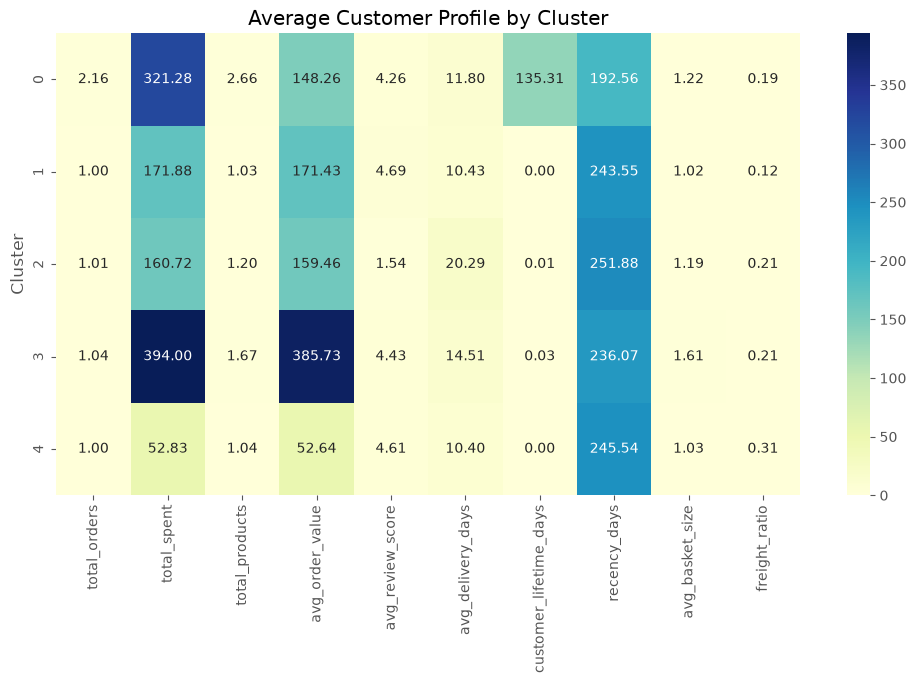

In [12]:
plt.figure(figsize=(12,6))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Average Customer Profile by Cluster")

plt.show()

## Spending Analysis

This section compares customer spending across clusters to identify high-value and low-value customer segments.

### 1. Average total spending by cluster

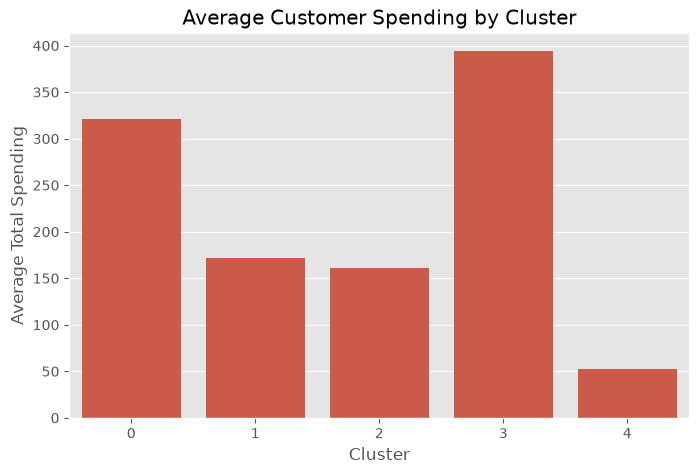

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=clusters_df,
    x="Cluster",
    y="total_spent",
    estimator="mean",
    errorbar=None
)

plt.title("Average Customer Spending by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Total Spending")

plt.show()

### 2. Average order value by cluster

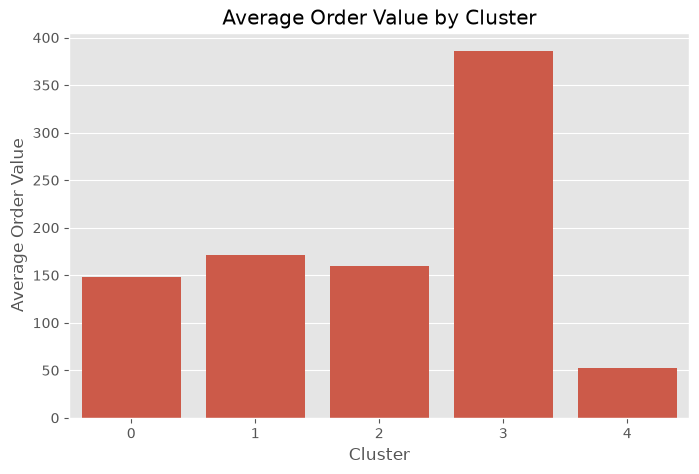

In [16]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=clusters_df,
    x="Cluster",
    y="avg_order_value",
    estimator="mean",
    errorbar=None
)

plt.title("Average Order Value by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Order Value")

plt.show()

## Purchase Behavior

This section compares purchasing frequency and basket size across customer segments.

### 1. Average orders

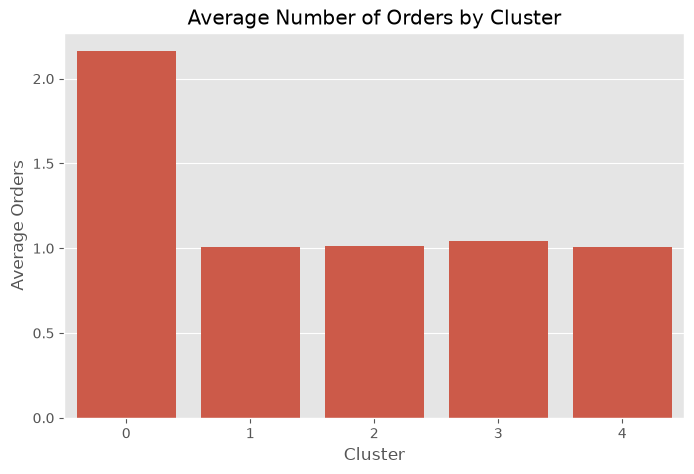

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=clusters_df,
    x="Cluster",
    y="total_orders",
    estimator="mean",
    errorbar=None
)

plt.title("Average Number of Orders by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Orders")

plt.show()

### 2. Average Basket size

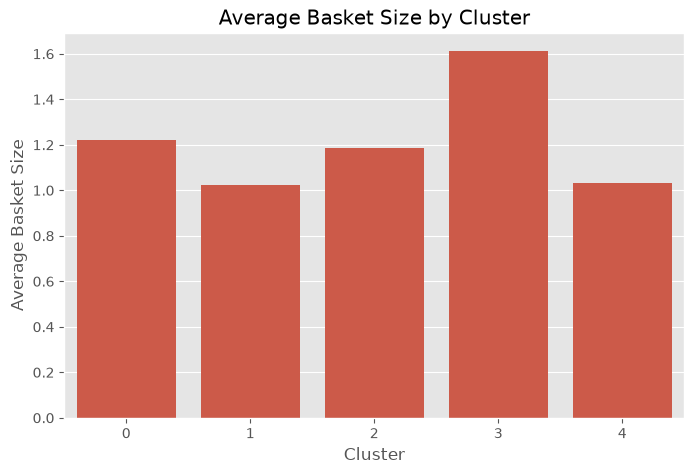

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=clusters_df,
    x="Cluster",
    y="avg_basket_size",
    estimator="mean",
    errorbar=None
)

plt.title("Average Basket Size by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Basket Size")

plt.show()

## Customer Satisfaction

This section evaluates customer satisfaction using average review scores across customer segments.

### 1. Average Review Score 

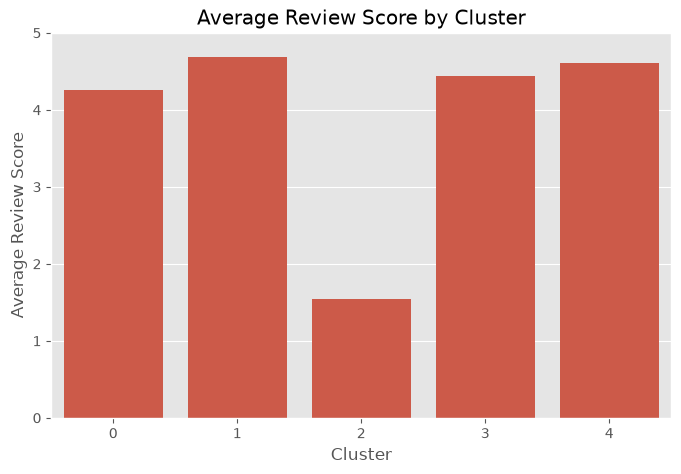

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=clusters_df,
    x="Cluster",
    y="avg_review_score",
    estimator="mean",
    errorbar=None
)

plt.title("Average Review Score by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Review Score")

plt.ylim(0,5)

plt.show()

## Delivery Performance

This section compares average delivery time across customer segments.

### 1. Delivery days

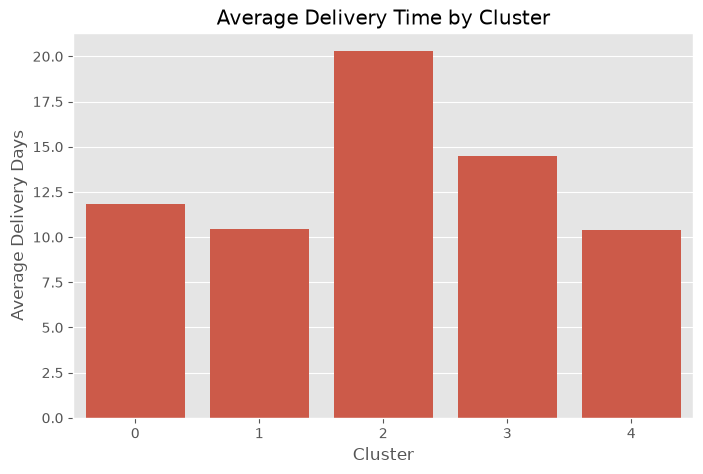

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=clusters_df,
    x="Cluster",
    y="avg_delivery_days",
    estimator="mean",
    errorbar=None
)

plt.title("Average Delivery Time by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Delivery Days")

plt.show()

## Customer Lifetime

This section compares customer longevity across clusters.

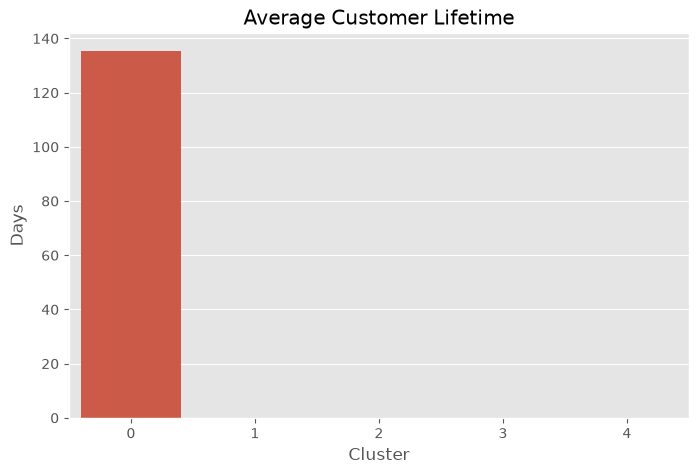

In [21]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=clusters_df,
    x="Cluster",
    y="customer_lifetime_days",
    estimator="mean",
    errorbar=None
)

plt.title("Average Customer Lifetime")
plt.xlabel("Cluster")
plt.ylabel("Days")

plt.show()

## Recency Analysis

This section compares how recently customers have made purchases across different customer segments.

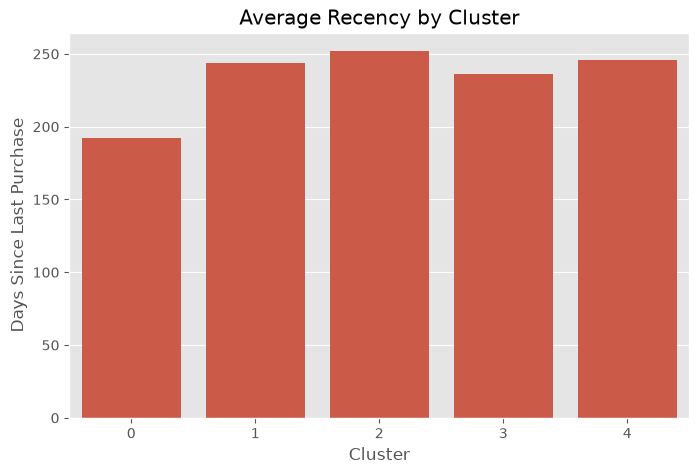

In [22]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=clusters_df,
    x="Cluster",
    y="recency_days",
    estimator="mean",
    errorbar=None
)

plt.title("Average Recency by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Days Since Last Purchase")

plt.show()

## Customer Personas

### 1. Create Cluster Summary

In [23]:
cluster_summary = (
    clusters_df
    .groupby("Cluster")
    .agg({
        "customer_unique_id": "count",
        "total_orders": "mean",
        "total_spent": "mean",
        "total_products": "mean",
        "avg_order_value": "mean",
        "avg_review_score": "mean",
        "avg_delivery_days": "mean",
        "customer_lifetime_days": "mean",
        "recency_days": "mean",
        "avg_basket_size": "mean",
        "freight_ratio": "mean"
    })
    .rename(columns={"customer_unique_id":"customers"})
    .round(2)
)

cluster_summary

,customers,total_orders,total_spent,total_products,avg_order_value,avg_review_score,avg_delivery_days,customer_lifetime_days,recency_days,avg_basket_size,freight_ratio
Cluster,,,,,,,,,,,
0,1886,2.16,321.28,2.66,148.26,4.26,11.80,135.31,192.56,1.22,0.19
1,34289,1.00,171.88,1.03,171.43,4.69,10.43,0.00,243.55,1.02,0.12
2,15605,1.01,160.72,1.20,159.46,1.54,20.29,0.01,251.88,1.19,0.21
3,13288,1.04,394.00,1.67,385.73,4.43,14.51,0.03,236.07,1.61,0.21
4,30351,1.00,52.83,1.04,52.64,4.61,10.40,0.00,245.54,1.03,0.31


### 2. Assign Cluster Names

In [24]:
cluster_names = {
    0: "Loyal Customers",
    1: "Regular Customers",
    2: "Dissatisfied Customers",
    3: "Premium Customers",
    4: "Budget Customers"
}

clusters_df["Customer_Segment"] = (
    clusters_df["Cluster"]
    .map(cluster_names)
)

### 3. Customer Disribution

In [25]:
segment_distribution = (
    clusters_df["Customer_Segment"]
    .value_counts()
)

segment_distribution

Customer_Segment
Regular Customers         34289
Budget Customers          30351
Dissatisfied Customers    15605
Premium Customers         13288
Loyal Customers            1886
Name: count, dtype: int64

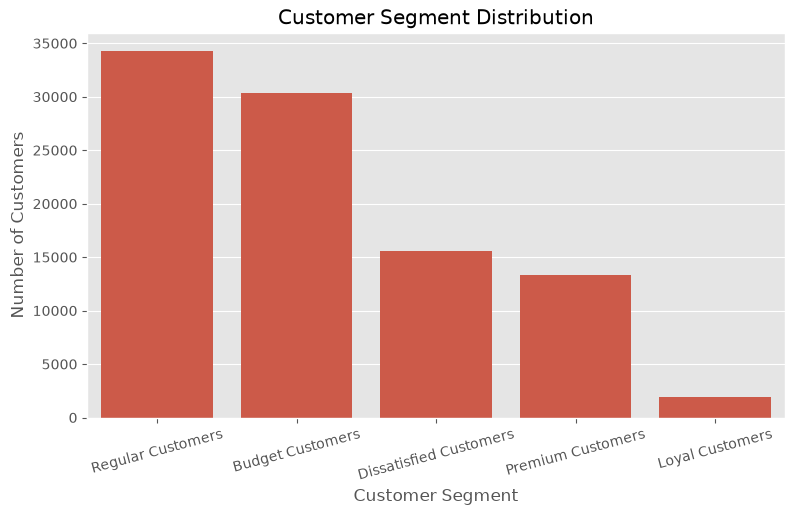

In [26]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=clusters_df,
    x="Customer_Segment",
    order=segment_distribution.index
)

plt.title("Customer Segment Distribution")

plt.xlabel("Customer Segment")

plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

### 4. Segment Summary Table

In [27]:
segment_profile = (
    clusters_df
    .groupby("Customer_Segment")
    .agg({
        "customer_unique_id":"count",
        "total_orders":"mean",
        "total_spent":"mean",
        "avg_order_value":"mean",
        "avg_review_score":"mean",
        "avg_delivery_days":"mean",
        "customer_lifetime_days":"mean",
        "recency_days":"mean"
    })
    .rename(columns={"customer_unique_id":"Customers"})
    .round(2)
)

segment_profile

,Customers,total_orders,total_spent,avg_order_value,avg_review_score,avg_delivery_days,customer_lifetime_days,recency_days
Customer_Segment,,,,,,,,
Budget Customers,30351,1.00,52.83,52.64,4.61,10.40,0.00,245.54
Dissatisfied Customers,15605,1.01,160.72,159.46,1.54,20.29,0.01,251.88
Loyal Customers,1886,2.16,321.28,148.26,4.26,11.80,135.31,192.56
Premium Customers,13288,1.04,394.00,385.73,4.43,14.51,0.03,236.07
Regular Customers,34289,1.00,171.88,171.43,4.69,10.43,0.00,243.55


### 5. Heatmap by Segment

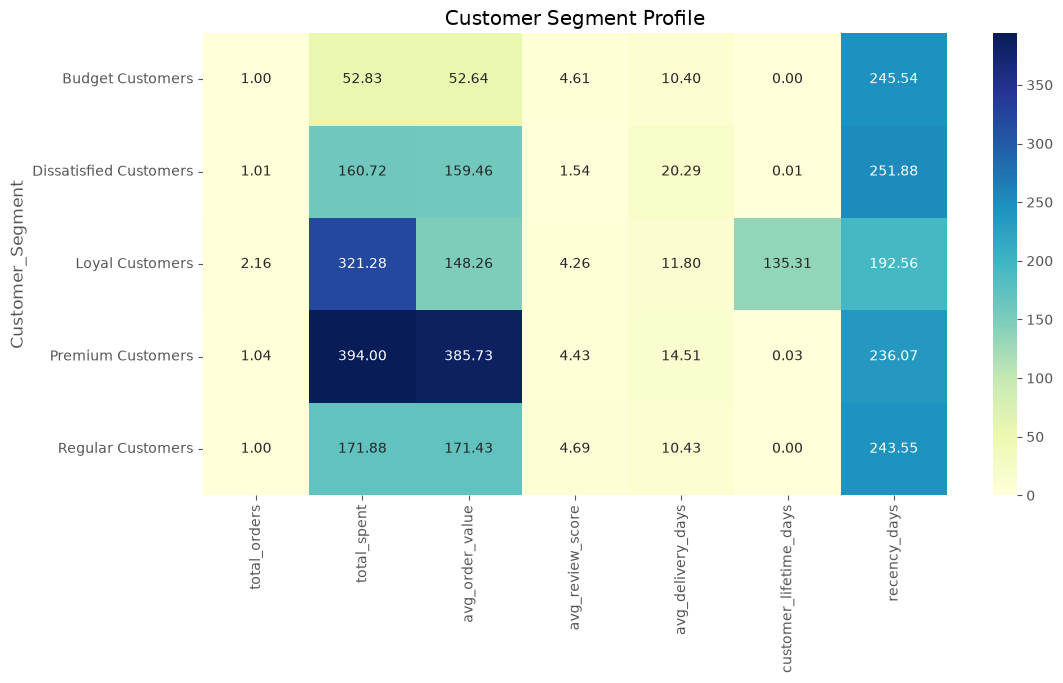

In [28]:
heatmap_data = (
    segment_profile
    .drop(columns="Customers")
)

plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Customer Segment Profile")

plt.show()

## Key Business Takeaways

The K-Means clustering model identified five distinct customer segments based on purchasing behavior, spending patterns, delivery experience, and customer satisfaction.

The analysis revealed that:

- Premium Customers generate the highest revenue and should be retained through personalized engagement.
- Loyal Customers exhibit the highest purchase frequency and represent long-term business value.
- Regular Customers form the largest customer segment and provide opportunities for increasing repeat purchases.
- Budget Customers are price-sensitive and respond well to discounts and bundled offers.
- Dissatisfied Customers experience lower satisfaction, primarily associated with longer delivery times, highlighting an opportunity to improve logistics and customer service.

These customer personas provide a foundation for targeted marketing campaigns, customer retention strategies, churn prediction, recommendation systems, and customer lifetime value analysis in the subsequent stages of the project.